# Working with a corpus: Vowels

* This notebook illustrates how one would extract phonetic measurements from a larger corpus.
* We will use "dir_to_df" from the fileorg repository to make a list of files to process
* Compute some phonetic measurements, and compile them into a big dataframe
* One feature of the demonstration here is that the phonetic tagging files in this corpus are not TextGrids (this is true of many corpora that are out there).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import phonlab as phon
from IPython.display import Audio
import seaborn as sns

# some new (to us) python libraries
import os                       # operating sytem functions
from pathlib import Path        # cross-platform file path references
from fileorganize import dir_to_df   # read a corpus into a dataframe

pd.set_option('future.no_silent_downcasting',True)  # set an option for pandas
sns.axes_style("darkgrid")  # set some themes for seaborn plots
sns.set_theme()

print(phon.__name__,phon.__version__)

phonlab 0.0.52


## a. Get a list of the wav files in the corpus

* the code here assumes that the corpus is in a folder under the current working directory
* if that isn't true you will need to give a fuller description of where to find the corpus
* dir_to_df() walks the directory tree into all subfolders under corpus_folder looking for wav files
* dir_to_df() also parses the filename and returns information encoded in the filename

In [2]:
folder = os.getcwd()
print(folder)  ## just so you know where we will be looking for the corpus

path_to_corpus = Path('./dimex')
path_to_results = Path('./temp')  # this notebook will create this directory if it doesn't already exist

corpus_list = dir_to_df(path_to_corpus,
               fnpat = r'(?P<subj>s\d\d\d)(?P<sentence>\d+)\.wav',
               addcols = ["dirname", "barename"])
corpus_list.head()

/Users/kjohnson/My Drive/Phonlab_workshop


,dirname,relpath,fname,barename,subj,sentence
0,dimex,.,s00801.wav,s00801,s008,01
1,dimex,.,s00802.wav,s00802,s008,02
2,dimex,.,s00803.wav,s00803,s008,03
3,dimex,.,s00804.wav,s00804,s008,04
4,dimex,.,s00805.wav,s00805,s008,05


## b. Compute formants and save

* ordinarily there will be a spreadsheet of information about each talker
* Here we will just construct a small data frame instead of reading in a talker info spreadsheet
* In addition to  demographics, we also include some analysis parameters for formant and pitch tracking

In [3]:
talkers = pd.DataFrame([["s008", "F", 6000, 10,1,[120,300]],
                        ["s019", "M", 5500, 12, 0, [60,220]],
                        ["s038", "F", 5500, 10, 1, [100,350]],
                        ["s050", "M", 5000, 12, 0, [50,200]],
                        ["s072", "F", 5500, 10, 1, [150,300]],
                        ["s090", "M", 5000, 12, 0, [80,240]]],
                       columns = ('subj','gender','ceiling', 'order','ifc_speaker','pitch_range'))
'''
    'ceiling':     a parameter used in Praat formant tracking
    'order':       for phonlab lpc formant tracking
    'ifc_speaker': for phonlab ifc formant tracking
    'pitch_range': for pitch tracking
'''

corpus_list = corpus_list.merge(talkers,on='subj', how='left') # add the talker information to the list
corpus_list.head()

,dirname,relpath,fname,barename,subj,sentence,gender,ceiling,order,ifc_speaker,pitch_range
0,dimex,.,s00801.wav,s00801,s008,01,F,6000,10,1,"[120, 300]"
1,dimex,.,s00802.wav,s00802,s008,02,F,6000,10,1,"[120, 300]"
2,dimex,.,s00803.wav,s00803,s008,03,F,6000,10,1,"[120, 300]"
3,dimex,.,s00804.wav,s00804,s008,04,F,6000,10,1,"[120, 300]"
4,dimex,.,s00805.wav,s00805,s008,05,F,6000,10,1,"[120, 300]"


## Here we implement a loop, which... 
* takes each row of the corpus list
* construct a new name for the results of formant analysis
* check to see if the results file already exists, or if we are planning to overwrite all of the old ones.
* loads the wav file
* tracks the formants in the file
* saves the formant tracking results in a csv file for later use


In [4]:
overwrite = True
for row in corpus_list.itertuples():
    wav_name = path_to_corpus / row.relpath / row.fname  # Full path to .wav file
    formant_name = f"{row.barename}_formants.csv"
    result_name = path_to_results / row.relpath / formant_name   # Full path to result
    if overwrite is True or not result_name.exists():
        x,fs = phon.loadsig(wav_name,chansel=[0])  # read in the audio
        #fdf = phon.track_formants(x,fs, method='ifc',
        #                          speaker = row.ifc_speaker,
        #                          order=row.order, 
        #                          f0_range = row.pitch_range,
        #                         quiet=True)  # compute formant frequencies

        fdf,A = phon.RLPC_formants(x,fs, order=row.order, l=0.025)  # compute formant frequencies
    
        result_name.parent.mkdir(parents=True, exist_ok=True)  # Make sure parent dir exists
        
        # Save formant measurements as .csv
        fdf.to_csv(result_name, index=False)
        print(f'Wrote formant results to {result_name}')

Wrote formant results to temp/s00801_formants.csv
Wrote formant results to temp/s00802_formants.csv
Wrote formant results to temp/s00803_formants.csv
Wrote formant results to temp/s00804_formants.csv
Wrote formant results to temp/s00805_formants.csv
Wrote formant results to temp/s01903_formants.csv
Wrote formant results to temp/s01904_formants.csv
Wrote formant results to temp/s01905_formants.csv
Wrote formant results to temp/s03801_formants.csv
Wrote formant results to temp/s03802_formants.csv
Wrote formant results to temp/s03803_formants.csv
Wrote formant results to temp/s03804_formants.csv
Wrote formant results to temp/s03805_formants.csv
Wrote formant results to temp/s05001_formants.csv
Wrote formant results to temp/s05002_formants.csv
Wrote formant results to temp/s05003_formants.csv
Wrote formant results to temp/s05004_formants.csv
Wrote formant results to temp/s05005_formants.csv
Wrote formant results to temp/s07201_formants.csv
Wrote formant results to temp/s07202_formants.csv


## c. Read and process one file

* In this block we build a function to read the tagging files in Dimex
* We will use [pandas.read_csv()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) to read the phonetic tags.
* Then we will elaborate the dataframe with additional information (like word position, stress, etc)
* and merge in the formant measurements
* This function "process_a_dimex_file()" can then be used to build a database of vowel formant frequencies

In [5]:

def add_stress_column(value):
    if value in ['i_7', 'e_7', 'a_7', 'o_7', 'u_7']:
        return 'stressed'
    elif value in ['i','e','a','o','u']:
        return 'unstressed'
    else:
        return None

def process_a_dimex_file(row):
    phontags = path_to_corpus / row.relpath / f"{row.barename}_phn.txt"  # first file on the list
    wordtags = path_to_corpus / row.relpath / f"{row.barename}_wrd.txt"

    # read the _phn.txt and _wrd.txt files
    phdf = pd.read_csv(phontags,sep=r'\s+',skiprows=2,names=['t1','t2','phone'])  # an analog to tg_to_df()
    phdf.t1 = phdf.t1/1000  # convert millisecond times to seconds
    phdf.t2 = phdf.t2/1000
    wddf = pd.read_csv(wordtags,sep=r'\s+',skiprows=2,names=['t1','t2','word'])
    wddf.t1 = wddf.t1/1000  # convert millisecond times to seconds
    wddf.t2 = wddf.t2/1000
    #print(phdf.head())

    ## ------------------ write the labels out to a textgrid ------------------------
    textgrid_name = path_to_results / row.relpath / f"{row.barename}.TextGrid"
    phon.df_to_tg([phdf,wddf],['phone','word'], outfile= textgrid_name) 
    ## ------------------------------------------------------------------------------

    # Now, let's put together a data frame for taking observations from the formants files
    phdf = phon.add_context(phdf,'phone',nprev=1,nnext=1)   # add phonetic context
    merged = phon.merge_tiers(phdf,wddf,suffixes=['','wd'])  # merge in the word tier

    # code each phonetic segment for word position
    merged['wordposition'] = 'medial'
    merged['wordposition'] = np.where(merged['t2'] == merged['t2wd'],"final",merged['wordposition'])
    merged['wordposition'] = np.where(merged['t1'] == merged['t1wd'],"initial",merged['wordposition'])

    # add some info from the corpus_list
    merged['speaker'] = row.subj 
    merged['gender'] = row.gender
    merged['sentence'] = row.sentence
    #print(merged.head())

    # add observation points for vowel measurements
    vowels = ['i_7', 'e_7', 'a_7', 'o_7', 'u_7', 'i', 'e', 'a', 'o', 'u']
    vowelsdf = merged.query(f'phone in {vowels}')  # make a dataframe that just has vowels
    vowelsdf = phon.explode_intervals([0.5], ts=['t1', 't2'], df=vowelsdf) # get times for observations

    # add vowel duration and stress information
    vowelsdf['vowel_dur'] = (vowelsdf['t2'] - vowelsdf['t1'])*1000  # add a vowel duration column
    vowelsdf['stress'] = vowelsdf['phone'].map(add_stress_column)  # use the pandas .map() function
    vowelsdf = vowelsdf.replace(to_replace = r'_7', value= r'', regex=True)  # take the '_7' off of the vowel symbols

    vowelsdf.drop(columns=['t1','t2','t1wd','t2wd'],inplace=True)  # drop the word onset/offset times
    #print(vowelsdf.head())

    # Now add the formant measurements to the dataframe 
    result_name = path_to_results / row.relpath / f"{row.barename}_formants.csv"
    fmtsdf = pd.read_csv(result_name)  # read in the csv of formants measurements

    vowelsdf = phon.interpolate_measures(
        meas_df=fmtsdf[['sec','F1', 'F2', 'F3', 'F4']],  # time axis and cols to interpolate
        meas_ts='sec',        # time index in the measurements dataframe
        interp_df=vowelsdf,       # textgrid dataframe
        interp_ts='obs_t',  # target observation times in the textgrid
        overwrite=True
    )
    
    return vowelsdf

df = process_a_dimex_file(corpus_list.iloc[0])  # try out the function on the first file in the corpus
print(df.shape)
df.head()

(17, 16)


,prev_phone1,phone,next_phone1,word,wordposition,speaker,gender,sentence,obs_t,obs_id,vowel_dur,stress,F1,F2,F3,F4
3,p,e,r(,pero,medial,s008,F,01,0.138035,0.5,64.839569,stressed,479.108195,2085.646690,2829.950024,4290.999056
5,r(,o,n,pero,final,s008,F,01,0.261029,0.5,60.828873,unstressed,64.143747,1506.649185,2981.665422,NaN
7,n,o,s,no,final,s008,F,01,0.412433,0.5,78.876984,unstressed,0.000000,694.015721,1485.020808,3304.579862
9,s,o,-R,solo,medial,s008,F,01,0.590575,0.5,63.502686,stressed,586.861092,1500.727816,2950.491889,3989.031652
12,l,o,a,solo,final,s008,F,01,0.723262,0.5,53.475952,unstressed,525.522522,1274.369185,2869.474912,3419.545793


## d.  Now process all of the files in the corpus

* Using the function defined above, we will read in all of the measurement
* Illustrating here the use of pandas.crosstab() to look over the data
* And seaborn.kdeplot() to visualize some of the measures


In [6]:
dflist = []
s = ""
for row in corpus_list.itertuples():
    if s != row.subj:  # print a new message when we get on to files from a new subject
        s = row.subj
        print(s)
    dflist.append(process_a_dimex_file(row))

all_data = pd.concat(dflist)   # all data contains data from all of the files in the corpus
all_data.shape

s008
s019
s038
s050
s072
s090


(580, 16)

### Apply vowel normalization

* a normalization function is defined in phonlab.

In [7]:

normalized = phon.deltaF_norm(all_data,column="speaker")
normalized.head()


,speaker,level_1,prev_phone1,phone,next_phone1,word,wordposition,gender,sentence,obs_t,...,stress,F1,F2,F3,F4,F1/∆F,F2/∆F,F3/∆F,F4/∆F,deltaF
0,s008,3,p,e,r(,pero,medial,F,01,0.138035,...,stressed,479.108195,2085.646690,2829.950024,4290.999056,0.486218,2.116599,2.871948,4.354680,985.376351
1,s008,5,r(,o,n,pero,final,F,01,0.261029,...,unstressed,64.143747,1506.649185,2981.665422,NaN,0.065096,1.529009,3.025915,NaN,985.376351
2,s008,7,n,o,s,no,final,F,01,0.412433,...,unstressed,0.000000,694.015721,1485.020808,3304.579862,0.000000,0.704315,1.507060,3.353622,985.376351
3,s008,9,s,o,-R,solo,medial,F,01,0.590575,...,stressed,586.861092,1500.727816,2950.491889,3989.031652,0.595571,1.523000,2.994279,4.048232,985.376351
4,s008,12,l,o,a,solo,final,F,01,0.723262,...,unstressed,525.522522,1274.369185,2869.474912,3419.545793,0.533322,1.293282,2.912060,3.470294,985.376351


## e. Exploring the big data frame

In [8]:
pd.crosstab(normalized.speaker,normalized.phone,margins=True)

phone,a,e,i,o,u,All
speaker,,,,,,
s008,31,33,18,22,7,111
s019,18,22,7,16,4,67
s038,36,19,8,12,7,82
s050,23,25,13,20,4,85
s072,32,40,18,30,4,124
s090,28,35,17,28,3,111
All,168,174,81,128,29,580


In [9]:
normalized[['speaker','F1/∆F']].groupby(['speaker']).describe()

F1/∆F                                                         \
         count      mean       std  min       25%       50%       75%   
speaker                                                                 
s008     111.0  0.295802  0.226966  0.0  0.001147  0.331876  0.469645   
s019      67.0  0.370115  0.179975  0.0  0.316339  0.410484  0.464639   
s038      82.0  0.451562  0.166265  0.0  0.354297  0.451618  0.563170   
s050      85.0  0.385063  0.198199  0.0  0.281603  0.413123  0.469551   
s072     124.0  0.409182  0.194736  0.0  0.327468  0.387683  0.443893   
s090     111.0  0.449226  0.149003  0.0  0.388041  0.459694  0.527962   

                   
              max  
speaker            
s008     0.972555  
s019     0.750052  
s038     1.123379  
s050     1.111984  
s072     1.486668  
s090     0.886848

<Axes: xlabel='F2', ylabel='Density'>

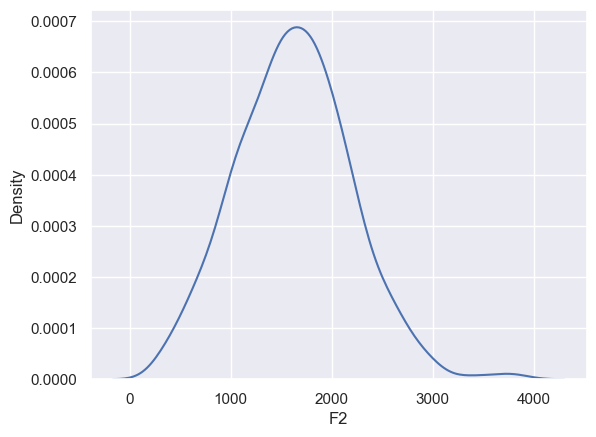

In [10]:
sns.kdeplot(normalized,x="F2",common_norm=False)

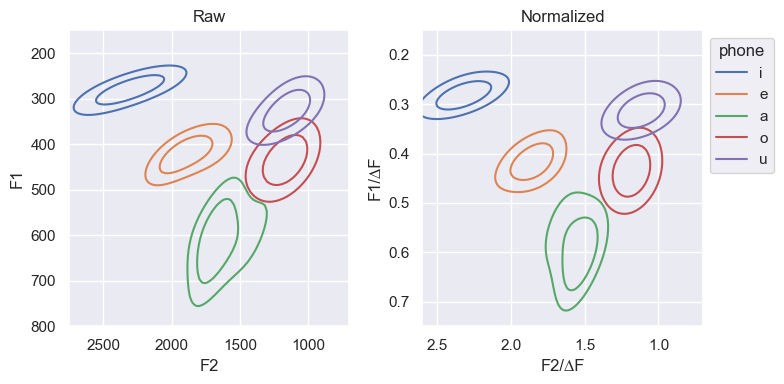

In [11]:

ho = ['i','e','a','o','u']
l = [0.75, 0.9]
xrange = [2.6,0.7]
yrange = [0.75,0.15]

fig1, axs = plt.subplots(ncols=2,figsize=(8,4))

sns.kdeplot(normalized,x="F2",y="F1",hue="phone",hue_order = ho,
            common_norm=False,levels=l,legend=False,ax=axs[0]).set(title="Raw")
axs[0].set_xlim((2750,700))
axs[0].set_ylim([800,150])

sns.kdeplot(normalized, x='F2/∆F',y='F1/∆F',hue="phone",hue_order= ho, 
            common_norm=False,levels=l,legend=True,ax=axs[1]).set(title="Normalized")
axs[1].set_xlim(xrange)
axs[1].set_ylim(yrange)
sns.move_legend(axs[1], "upper left", bbox_to_anchor=(1, 1))
fig1.tight_layout()

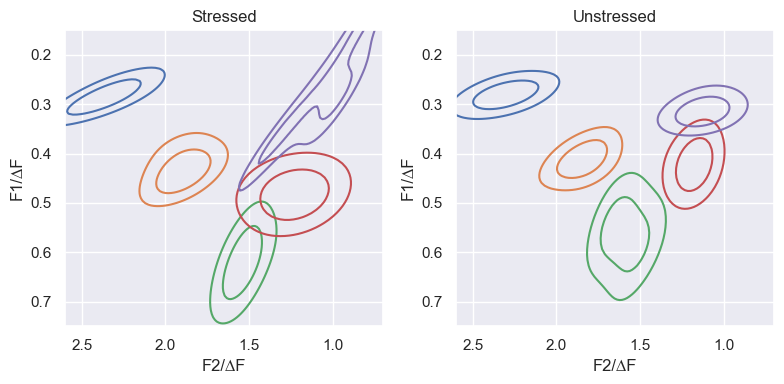

In [12]:
fig1, axs = plt.subplots(ncols=2,figsize=(8,4))


ho = ['i','e','a','o','u']


sns.kdeplot(normalized[normalized['stress'] == "stressed"],
            x='F2/∆F',y='F1/∆F',hue="phone",hue_order= ho, ax = axs[0],
            common_norm=False,levels=l,legend=False).set(title="Stressed")
sns.kdeplot(normalized[normalized['stress'] == "unstressed"],
            x='F2/∆F',y='F1/∆F',hue="phone",hue_order= ho, ax = axs[1],
            common_norm=False,levels=l,legend=False).set(title="Unstressed")
axs[0].set_xlim(xrange)
axs[0].set_ylim(yrange)
axs[1].set_xlim(xrange)
axs[1].set_ylim(yrange)
fig1.tight_layout()

In [14]:
pd.crosstab(normalized.stress,normalized.phone,margins=True)

phone,a,e,i,o,u,All
stress,,,,,,
stressed,54,40,22,30,3,149
unstressed,114,134,59,98,26,431
All,168,174,81,128,29,580
